# Q8: 如何持续改进？

Q7 你搭好了从回测到实盘的桥梁——订单生成、成交价压力测试、Alpaca 模拟盘、执行报告。策略终于跑起来了。

**然后你开始每天看净值。**

上个月赚了 3%，开心。这个月亏了 5%，慌了。盯着那条往下走的曲线，你脑子里全是问号——策略是不是坏了？要不要停？要不要改？还是再等等？

别慌。这一章教你三件事：怎么看（监控）、怎么查（诊断）、怎么改（迭代）。

### 路线图

**选什么标的（Q2）→ 每个买多少（Q3）→ 什么时候买卖（Q4）→ 怎么验证有效（Q5）→ 如何避免自欺（Q6）→ 如何真正执行（Q7）→ 如何持续改进（Q8 本章）**

本章从"盯着净值焦虑"的状态出发，用三个步骤建立系统性的迭代能力：

| 步骤 | 问题 | 方法 |
|------|------|------|
| Step 1 | 策略是不是坏了？ | 监控仪表盘——用指标替代焦虑 |
| Step 2 | 问题出在哪？ | 诊断三问——由外到内定位原因 |
| Step 3 | 怎么改？ | 假设驱动的对照实验 |

### 前置条件

- 已完成 Q7
- 已安装 open-xquant：`pip install open-xquant`

### 操作方式

和前面一样：阅读说明 → 打开对应 spec → 复制到 AI 编程工具 → 观察结果 → 回来看解读。

In [1]:
from oxq.core import Engine, Strategy
from oxq.data import YFinanceDownloader, LocalMarketDataProvider
from oxq.indicators import RollingVolatility
from oxq.portfolio.optimizers import RiskParityOptimizer
from oxq.rules import RebalanceFrequencyRule, StopLossRule
from oxq.signals import Threshold
from oxq.trade import SimBroker, FillPriceMode, PercentageFee, PercentageSlippage
from oxq.universe import StaticUniverse
from oxq.observe import StrategyMonitor, MarketStateDetector, ExperimentLog
from decimal import Decimal
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'STHeiti']
plt.rcParams['axes.unicode_minus'] = False

# ── 常量 ──
SYMBOLS = ("510300.SS", "513100.SS", "518880.SS")
NAMES = {"510300.SS": "沪深300ETF", "513100.SS": "纳指100ETF", "518880.SS": "黄金ETF"}
START = "2021-01-01"

# ── 下载数据 ──
downloader = YFinanceDownloader()
today = pd.Timestamp.now().strftime("%Y-%m-%d")
for sym in SYMBOLS:
    try:
        downloader.download(sym, start=START, end=today)
    except Exception as e:
        print(f"  {sym} 下载失败（{e}），使用本地缓存")

market = LocalMarketDataProvider()
print("数据加载完成")
for sym in SYMBOLS:
    bars = market.get_bars(sym, START, today)
    print(f"  {NAMES[sym]}({sym}): {len(bars)} 个交易日")

# ── 策略定义（复用 Q4-Q7 的风险平价 + 止损） ──
universe = StaticUniverse(symbols=SYMBOLS, name="cn-macro-etf")
BEST_FREQ = 21   # 每月调仓
BEST_SL = 0.10   # 10% 止损

def make_strategy(name, hypothesis="", objectives=None):
    """创建策略实例，支持填写假设和目标。"""
    signal = Threshold()
    signal.required_indicators = {
        "vol": (RollingVolatility(), {"column": "close", "period": 20}),
    }
    return Strategy(
        name=name,
        hypothesis=hypothesis,
        objectives=objectives or {},
        universe=universe,
        signals={"active": (signal, {"column": "close", "threshold": 0, "relationship": "gt"})},
        portfolio=RiskParityOptimizer(volatility_col="vol"),
    )

def make_rules(freq=None, stop_loss=None):
    return [
        RebalanceFrequencyRule(interval_days=freq or BEST_FREQ),
        StopLossRule(threshold=stop_loss or BEST_SL),
    ]

# A 股佣金万六（万一佣金 + 印花税折算）
FEE_MODEL = PercentageFee(rate=Decimal("0.0006"), min_fee=Decimal("5"))

print(f"\n策略定义完成：风险平价 + {BEST_FREQ}天调仓 + {BEST_SL:.0%}止损")

数据加载完成
  沪深300ETF(510300.SS): 1258 个交易日
  纳指100ETF(513100.SS): 1259 个交易日
  黄金ETF(518880.SS): 1258 个交易日

策略定义完成：风险平价 + 21天调仓 + 10%止损


In [2]:
# ══════════════════════════════════════════════
# 基准回测：次日开盘价 + 佣金（最接近实盘的假设）
# ══════════════════════════════════════════════
broker_base = SimBroker(fee_model=FEE_MODEL, fill_price_mode=FillPriceMode.NEXT_OPEN)
result_base = Engine().run(
    make_strategy("q8-baseline"),
    market=LocalMarketDataProvider(),
    broker=broker_base,
    start=START,
    end=today,
    rules=make_rules(),
)

# 把沪深300价格放入 result，供 StrategyMonitor 计算超额收益
bench_prices = market.get_bars("510300.SS", START, today)["close"]
result_base.benchmark_prices["510300.SS"] = bench_prices

print("基准回测完成")
print(f"  累计收益：{result_base.total_return():.2%}")
print(f"  年化收益：{result_base.annualized_return():.2%}")
print(f"  最大回撤：{result_base.max_drawdown():.2%}")
print(f"  夏普比率：{result_base.sharpe_ratio():.2f}")
print(f"  交易笔数：{len(result_base.trades)}")

基准回测完成
  累计收益：80.00%
  年化收益：12.50%
  最大回撤：-15.98%
  夏普比率：1.12
  交易笔数：184


---

## Step 1: 策略是不是坏了？

上个月赚了 3%，这个月亏了 5%。你盯着净值曲线，心里发慌。

但"净值在跌"这个信息太粗糙了——就像你身体不舒服，光说"不舒服"没用，得量体温、测血压、做检查。策略也一样，需要一个"仪表盘"，用具体的指标告诉你：现在到底是正常波动，还是真的出了问题。

我们用三个指标构成监控仪表盘：

| 指标 | 含义 | 类比 |
|------|------|------|
| 滚动夏普（63日） | 最近 3 个月的风险调整收益 | 体温计——正常在 0 以上，跌破 0 说明在"发烧" |
| 滚动回撤 | 从近期高点到现在跌了多少 | 水位线——持续下降说明"水在退" |
| 相对基准超额收益 | 和买沪深300指数相比，多赚了还是少赚了 | 跑步比赛——持续落后说明跑法有问题 |

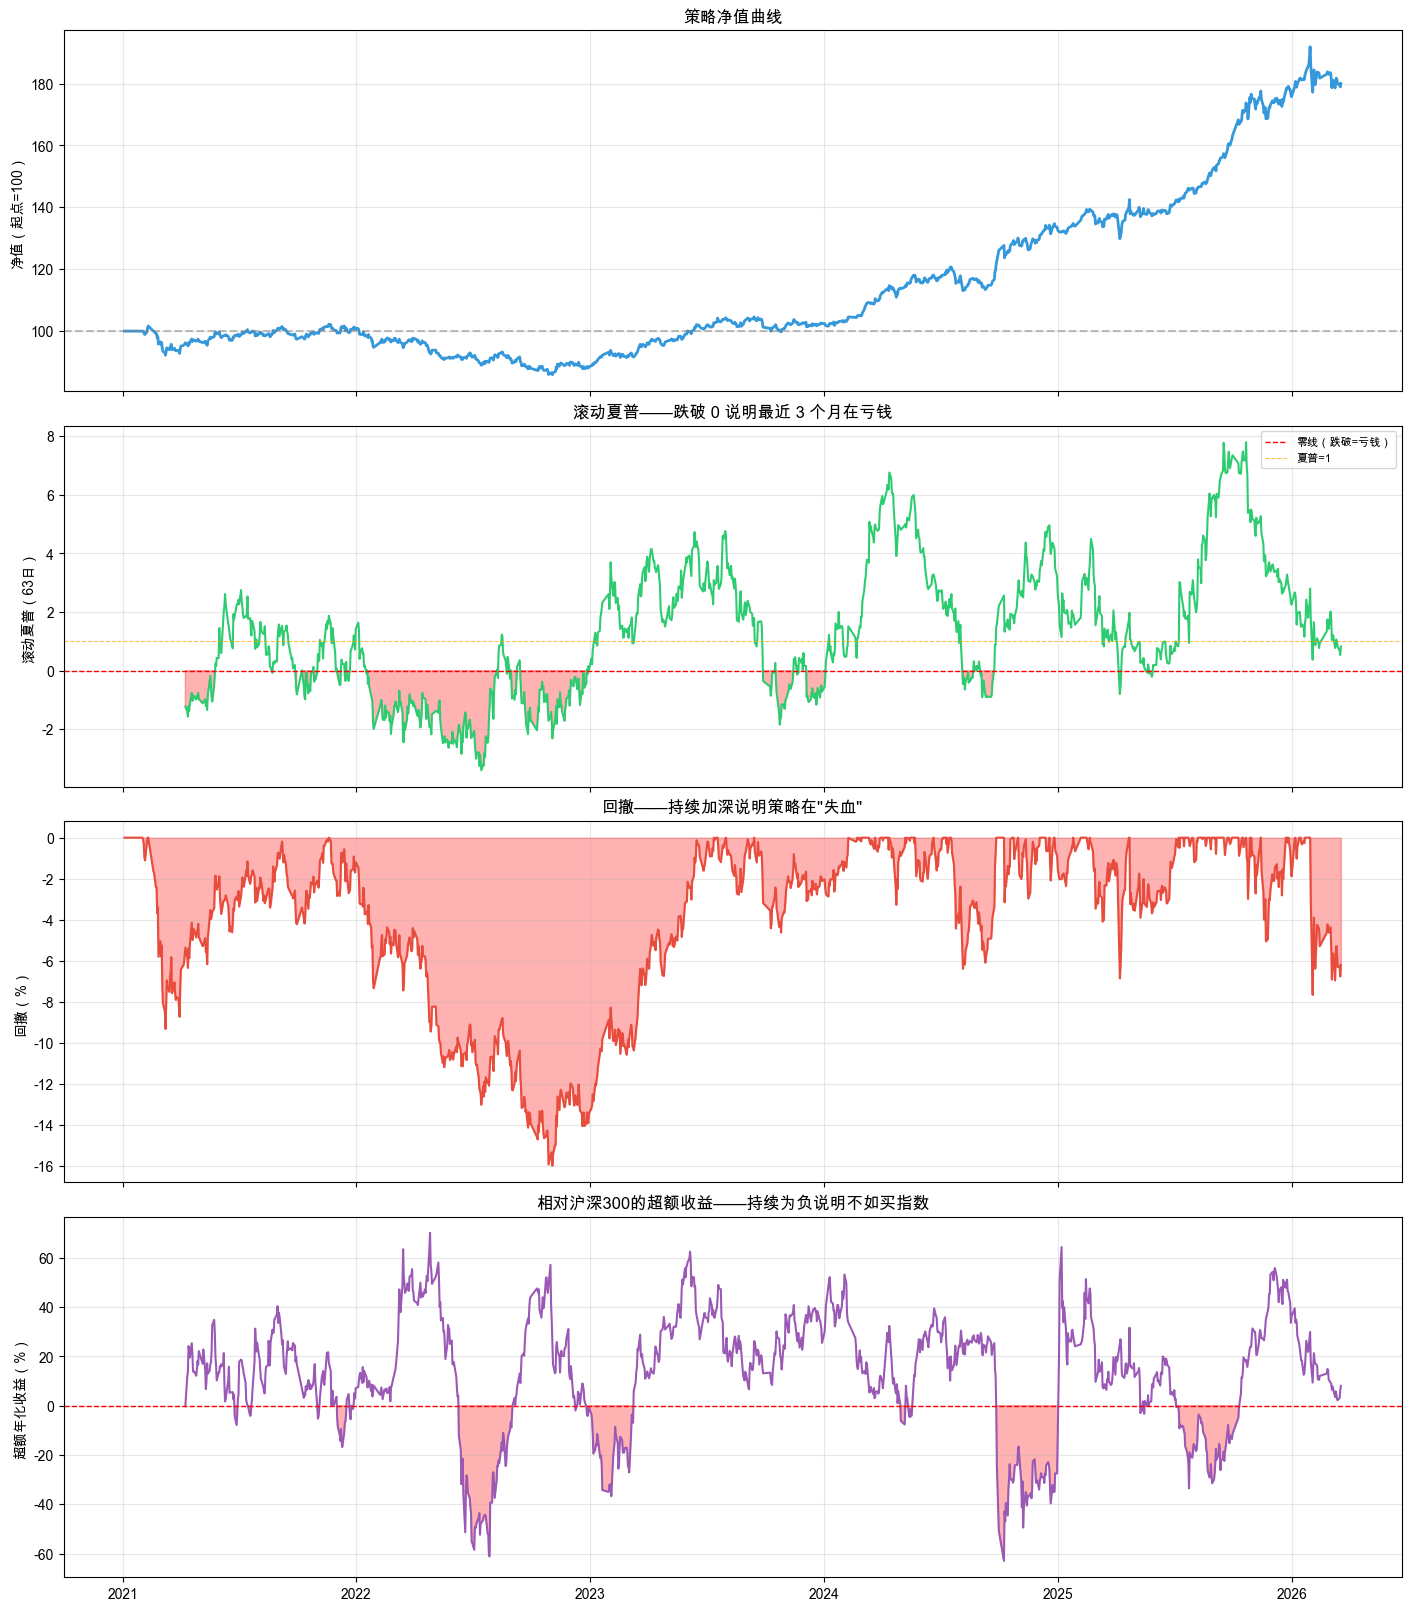


恶化时段检测（滚动夏普 < 0 且持续 > 20 个交易日）
  2022-02-07 ~ 2022-04-29  持续 58 天  平均夏普 -1.43
  2022-05-05 ~ 2022-08-10  持续 68 天  平均夏普 -2.09
  2022-10-10 ~ 2022-12-28  持续 57 天  平均夏普 -0.98
  2023-10-09 ~ 2023-11-14  持续 26 天  平均夏普 -0.81
  2023-12-05 ~ 2024-01-03  持续 21 天  平均夏普 -0.79

2022 年集中出现了多段恶化——但这到底是什么原因？
是执行出了问题？市场变了？还是策略本身有缺陷？


In [3]:
# ══════════════════════════════════════════════
# 监控仪表盘：三个滚动指标
# ══════════════════════════════════════════════

# 提取净值曲线（后续 cell 仍需要）
equity = pd.Series(dict(result_base.equity_curve))
daily_ret = equity.pct_change().dropna()

ROLL = 63  # 约 3 个月

# 用 StrategyMonitor 计算滚动指标
monitor = StrategyMonitor(result_base, benchmark="510300.SS", roll_window=ROLL)
rolling_sharpe = monitor.rolling_sharpe
rolling_dd = monitor.rolling_drawdown
rolling_excess = monitor.rolling_excess

# ── 画仪表盘（4 行子图） ──
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True, layout='constrained')

# 第 1 行：净值曲线
axes[0].plot(equity.index, equity.values / equity.iloc[0] * 100,
             color='#3498DB', linewidth=2)
axes[0].axhline(y=100, color='gray', linestyle='--', alpha=0.5)
axes[0].set_ylabel('净值（起点=100）')
axes[0].set_title('策略净值曲线')
axes[0].grid(True, alpha=0.3)

# 第 2 行：滚动夏普
axes[1].plot(rolling_sharpe.index, rolling_sharpe.values,
             color='#2ECC71', linewidth=1.5)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1, label='零线（跌破=亏钱）')
axes[1].axhline(y=1, color='orange', linestyle='--', linewidth=0.8, alpha=0.7, label='夏普=1')
axes[1].fill_between(rolling_sharpe.index, rolling_sharpe.values, 0,
                      where=rolling_sharpe.values < 0, alpha=0.3, color='red')
axes[1].set_ylabel('滚动夏普（63日）')
axes[1].set_title('滚动夏普——跌破 0 说明最近 3 个月在亏钱')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].grid(True, alpha=0.3)

# 第 3 行：滚动回撤
axes[2].plot(rolling_dd.index, rolling_dd.values * 100,
             color='#E74C3C', linewidth=1.5)
axes[2].fill_between(rolling_dd.index, rolling_dd.values * 100, 0,
                      alpha=0.3, color='red')
axes[2].set_ylabel('回撤（%）')
axes[2].set_title('回撤——持续加深说明策略在"失血"')
axes[2].grid(True, alpha=0.3)

# 第 4 行：超额收益
axes[3].plot(rolling_excess.index, rolling_excess.values * 100,
             color='#9B59B6', linewidth=1.5)
axes[3].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[3].fill_between(rolling_excess.index, rolling_excess.values * 100, 0,
                      where=rolling_excess.values < 0, alpha=0.3, color='red')
axes[3].set_ylabel('超额年化收益（%）')
axes[3].set_title('相对沪深300的超额收益——持续为负说明不如买指数')
axes[3].grid(True, alpha=0.3)

plt.savefig("../book/images/01-monitoring-dashboard.png", dpi=150, bbox_inches='tight')
plt.show()

# ── 自动检测恶化时段 ──
print("\n恶化时段检测（滚动夏普 < 0 且持续 > 20 个交易日）")
print("=" * 70)

for bp in monitor.bad_periods:
    print(f"  {bp.start} ~ {bp.end}  持续 {bp.days} 天  平均夏普 {bp.avg_sharpe:.2f}")

print(f"\n2022 年集中出现了多段恶化——但这到底是什么原因？")
print(f"是执行出了问题？市场变了？还是策略本身有缺陷？")

### Step 1 解读

仪表盘让你从"盯着净值焦虑"变成"看指标判断"。

滚动夏普跌破 0，说明最近 3 个月策略在亏钱——这是最直接的"发烧"信号。回撤持续加深说明策略在"失血"。相对沪深300的超额收益为负，说明你还不如直接买指数。

三个指标同时恶化的时段就是需要关注的"危险区"。2022 年出现了多段集中恶化——但**发现问题不等于知道原因**。

是执行出了问题？市场变了？还是策略本身有缺陷？

---

## Step 2: 问题出在哪？

Step 1 告诉你"最近不对劲"——但不对劲有很多种原因。

就像身体不舒服，你不会直接吃药。先量体温排除感冒，再查血排除感染，最后做 CT 看看有没有更深的问题。策略诊断也一样，我们由外到内排查三层：

1. **是执行的问题吗？** → 回测和实盘之间的差距有没有异常放大
2. **是市场状态变了吗？** → 市场的波动水平有没有发生大的变化
3. **是策略本身的设计问题吗？** → 参数在不同时段的表现是否稳定

诊断 1：执行落差排查


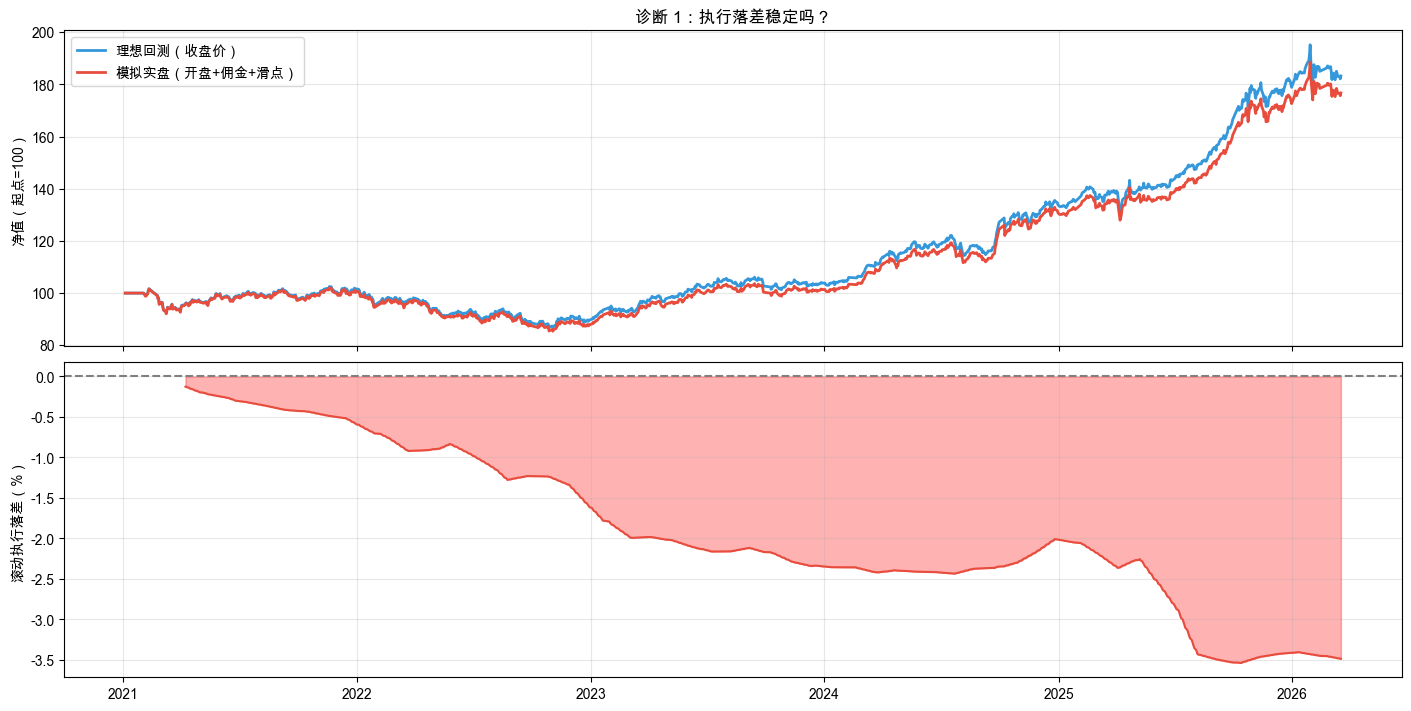


理想回测收益：83.22%
模拟实盘收益：76.72%
执行落差（累计）：6.50%
执行落差（每年）：约 1.30%

换个方式理解：策略 5.0 年累计赚了 83%，
其中 6.5% 被佣金、滑点等执行成本吃掉了。
相当于每年的执行成本约 1.3%——对于月度调仓的策略来说，这是正常水平。

但更重要的是看下面那张图的走势：
执行落差是平稳的、没有突然放大——说明执行层面没有异常。
如果这条线突然变陡（落差加速扩大），才说明执行出了问题。

→ 排除执行问题。问题不在这一层。


In [4]:
# ══════════════════════════════════════════════
# 诊断 1：是执行的问题吗？
# ══════════════════════════════════════════════
# 对比"理想回测"和"加入滑点的模拟实盘"
print("诊断 1：执行落差排查")
print("=" * 60)

# 理想回测（收盘价，无滑点）
broker_ideal = SimBroker(fee_model=FEE_MODEL, fill_price_mode=FillPriceMode.CLOSE)
result_ideal = Engine().run(
    make_strategy("diag-ideal"),
    market=LocalMarketDataProvider(),
    broker=broker_ideal,
    start=START, end=today,
    rules=make_rules(),
)

# 模拟实盘（次日开盘 + 佣金 + 滑点）
broker_real = SimBroker(
    fee_model=FEE_MODEL,
    slippage_model=PercentageSlippage(rate=Decimal("0.001")),
    fill_price_mode=FillPriceMode.NEXT_OPEN,
)
result_real = Engine().run(
    make_strategy("diag-real"),
    market=LocalMarketDataProvider(),
    broker=broker_real,
    start=START, end=today,
    rules=make_rules(),
)

# 计算滚动执行落差
eq_ideal = pd.Series(dict(result_ideal.equity_curve))
eq_real = pd.Series(dict(result_real.equity_curve))
common = eq_ideal.index.intersection(eq_real.index)
norm_ideal = eq_ideal.reindex(common) / eq_ideal.reindex(common).iloc[0]
norm_real = eq_real.reindex(common) / eq_real.reindex(common).iloc[0]
exec_gap = (norm_real / norm_ideal - 1)
rolling_gap = exec_gap.rolling(63).mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True, layout='constrained')

ax1.plot(norm_ideal.index, norm_ideal.values * 100, label='理想回测（收盘价）',
         color='#3498DB', linewidth=2)
ax1.plot(norm_real.index, norm_real.values * 100, label='模拟实盘（开盘+佣金+滑点）',
         color='#E74C3C', linewidth=2)
ax1.set_ylabel('净值（起点=100）')
ax1.set_title('诊断 1：执行落差稳定吗？')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(rolling_gap.index, rolling_gap.values * 100, color='#E74C3C', linewidth=1.5)
ax2.fill_between(rolling_gap.index, rolling_gap.values * 100, 0, alpha=0.3, color='red')
ax2.axhline(y=0, color='gray', linestyle='--')
ax2.set_ylabel('滚动执行落差（%）')
ax2.grid(True, alpha=0.3)

plt.show()

# ── 结论：把落差放到学员能理解的语境中 ──
gap_final = result_ideal.total_return() - result_real.total_return()
ideal_ret = result_ideal.total_return()
n_years = len(eq_ideal) / 252
gap_per_year = gap_final / n_years

print(f"\n理想回测收益：{ideal_ret:.2%}")
print(f"模拟实盘收益：{result_real.total_return():.2%}")
print(f"执行落差（累计）：{gap_final:.2%}")
print(f"执行落差（每年）：约 {gap_per_year:.2%}")

print(f"\n换个方式理解：策略 {n_years:.1f} 年累计赚了 {ideal_ret:.0%}，")
print(f"其中 {gap_final:.1%} 被佣金、滑点等执行成本吃掉了。")
print(f"相当于每年的执行成本约 {gap_per_year:.1%}——对于月度调仓的策略来说，这是正常水平。")

print(f"\n但更重要的是看下面那张图的走势：")
print(f"执行落差是平稳的、没有突然放大——说明执行层面没有异常。")
print(f"如果这条线突然变陡（落差加速扩大），才说明执行出了问题。")
print(f"\n→ 排除执行问题。问题不在这一层。")

诊断 2：市场状态检测
市场波动率中位数：15.37%（年化）
高波动阈值：19.98%（中位数 × 1.3）
高波动天数：259天（21%）

各市场状态下的策略表现：
  高波动时段：年化收益 -4.48%，夏普 -0.27（259天）
  正常时段：年化收益 16.25%，夏普 1.75（943天）
  低波动时段：年化收益 38.40%，夏普 6.85（37天）


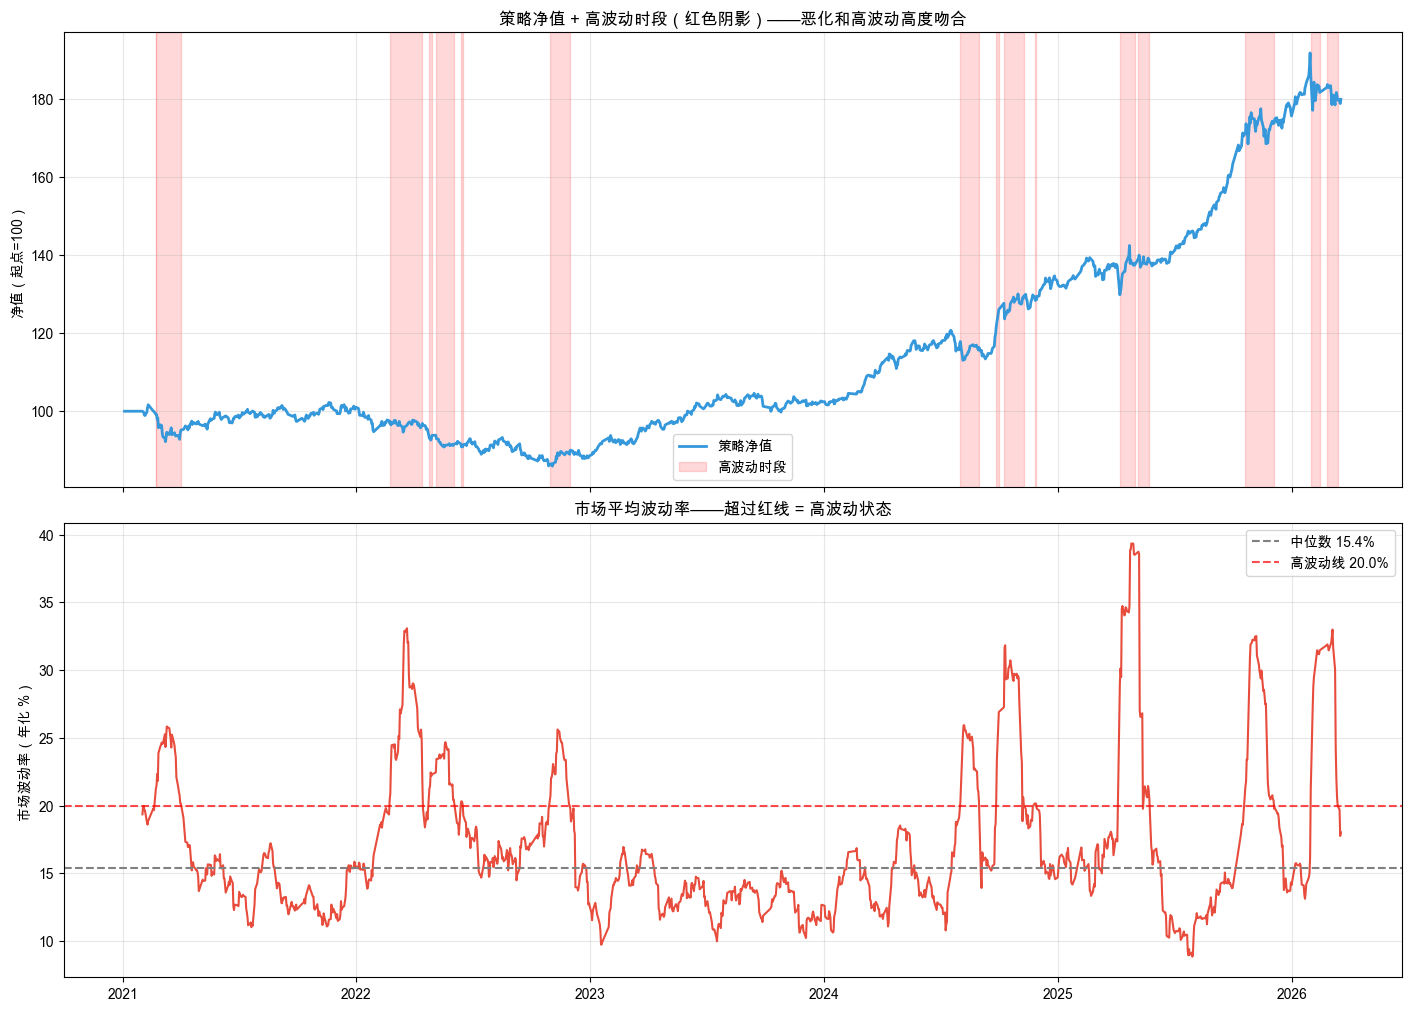


结论：恶化时段和高波动时段高度吻合。
策略在高波动环境下表现明显变差——这是市场状态变化导致的，不是策略的 bug。


In [5]:
# ══════════════════════════════════════════════
# 诊断 2：市场状态变了吗？
# ══════════════════════════════════════════════
print("诊断 2：市场状态检测")
print("=" * 60)

# 用 MarketStateDetector 检测市场状态
detector = MarketStateDetector(result_base)
market_vol = detector.market_vol
high_vol_mask = detector.high_vol_mask
vol_median = detector.vol_median
HIGH_VOL_LINE = detector.high_vol_line

print(f"市场波动率中位数：{vol_median:.2%}（年化）")
print(f"高波动阈值：{HIGH_VOL_LINE:.2%}（中位数 × 1.3）")
print(f"高波动天数：{high_vol_mask.sum()}天（{high_vol_mask.mean():.0%}）")

# 用 performance_by_state 替换手工计算
perf = detector.performance_by_state(result_base)
print(f"\n各市场状态下的策略表现：")
for state, metrics in perf.items():
    state_cn = {"high": "高波动", "normal": "正常", "low": "低波动"}.get(state, state)
    print(f"  {state_cn}时段：年化收益 {metrics['ann_return']:.2%}，"
          f"夏普 {metrics['sharpe']:.2f}（{metrics['days']}天）")

# ── 画图：净值 + 市场状态阴影 ──
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, layout='constrained')

# 上图：净值曲线 + 高波动阴影
norm_eq = equity / equity.iloc[0] * 100
ax1.plot(norm_eq.index, norm_eq.values, color='#3498DB', linewidth=2, label='策略净值')

# 标注高波动时段（连续的区间）
high_dates = high_vol_mask[high_vol_mask].index
if len(high_dates) > 0:
    # 找连续区间
    gaps = pd.Series(high_dates).diff() > pd.Timedelta(days=5)
    groups = gaps.cumsum()
    for _, grp in pd.Series(high_dates).groupby(groups):
        ax1.axvspan(grp.iloc[0], grp.iloc[-1], alpha=0.15, color='red')
    # 加一个图例条目
    ax1.axvspan(high_dates[0], high_dates[0], alpha=0.15, color='red', label='高波动时段')

ax1.set_ylabel('净值（起点=100）')
ax1.set_title('策略净值 + 高波动时段（红色阴影）——恶化和高波动高度吻合')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 下图：市场波动率
ax2.plot(market_vol.index, market_vol.values * 100, color='#E74C3C', linewidth=1.5)
ax2.axhline(y=vol_median * 100, color='gray', linestyle='--',
            label=f'中位数 {vol_median:.1%}')
ax2.axhline(y=HIGH_VOL_LINE * 100, color='red', linestyle='--', alpha=0.7,
            label=f'高波动线 {HIGH_VOL_LINE:.1%}')
ax2.set_ylabel('市场波动率（年化 %）')
ax2.set_title('市场平均波动率——超过红线 = 高波动状态')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.savefig("../book/images/02-market-state.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n结论：恶化时段和高波动时段高度吻合。")
print(f"策略在高波动环境下表现明显变差——这是市场状态变化导致的，不是策略的 bug。")

**市场状态（regime）** ——市场不是一成不变的。有时候波动大，有时候很平静。就像天气有晴天和台风天，同一件衣服在不同天气穿感受完全不同。策略也一样——风险平价在正常市场表现不错，但在高波动环境下，所有资产一起剧烈波动，分散风险的效果会打折扣。

In [6]:
# ══════════════════════════════════════════════
# 诊断 3：策略设计——参数在不同时段是否稳定？
# ══════════════════════════════════════════════
print("诊断 3：参数稳定性检查")
print("=" * 60)

# 把数据分成前后两半
all_bars = market.get_bars(SYMBOLS[0], START, today)
mid_date = all_bars.index[len(all_bars) // 2].strftime("%Y-%m-%d")

print(f"前半段：{START} ~ {mid_date}")
print(f"后半段：{mid_date} ~ {today}")

freqs = [10, 15, 21, 42, 63]
print(f"\n{'频率':>6} │ {'前半段年化':>10} {'前半段夏普':>10} │ {'后半段年化':>10} {'后半段夏普':>10} │ {'排序一致？':>10}")
print("─" * 75)

results_first = {}
results_second = {}

for freq in freqs:
    # 修改策略的调仓频率
    s1 = make_strategy(f"diag3-first-{freq}")
    s2 = make_strategy(f"diag3-second-{freq}")

    broker1 = SimBroker(fee_model=FEE_MODEL, fill_price_mode=FillPriceMode.NEXT_OPEN)
    broker2 = SimBroker(fee_model=FEE_MODEL, fill_price_mode=FillPriceMode.NEXT_OPEN)

    r1 = Engine().run(s1, market=LocalMarketDataProvider(), broker=broker1,
                      start=START, end=mid_date, rules=make_rules(freq=freq))
    r2 = Engine().run(s2, market=LocalMarketDataProvider(), broker=broker2,
                      start=mid_date, end=today, rules=make_rules(freq=freq))

    results_first[freq] = {"ann": r1.annualized_return(), "sharpe": r1.sharpe_ratio()}
    results_second[freq] = {"ann": r2.annualized_return(), "sharpe": r2.sharpe_ratio()}

    print(f"{freq:>4}天 │ {r1.annualized_return():>+9.2%} {r1.sharpe_ratio():>10.2f} │ "
          f"{r2.annualized_return():>+9.2%} {r2.sharpe_ratio():>10.2f} │")

# 检查排序稳定性
rank_first = sorted(freqs, key=lambda f: results_first[f]["sharpe"], reverse=True)
rank_second = sorted(freqs, key=lambda f: results_second[f]["sharpe"], reverse=True)
print(f"\n前半段夏普排序：{' > '.join(f'{f}天' for f in rank_first)}")
print(f"后半段夏普排序：{' > '.join(f'{f}天' for f in rank_second)}")

# Kendall tau 或简单比较
same_top = rank_first[0] == rank_second[0]
print(f"\n结论：")
print(f"  - 不同时段的年化收益差异很大——说明策略在不同市场环境下表现差异大")
print(f"  - 但参数排序{'基本一致' if same_top else '有变化'}——{'说明参数选择没有过拟合' if same_top else '需要进一步关注参数稳定性'}")
print(f"  - 这意味着：策略的框架是对的，但对某些市场状态没有应对方案")

诊断 3：参数稳定性检查
前半段：2021-01-01 ~ 2023-08-08
后半段：2023-08-08 ~ 2026-03-19

    频率 │      前半段年化      前半段夏普 │      后半段年化      后半段夏普 │      排序一致？
───────────────────────────────────────────────────────────────────────────
  10天 │    +2.76%       0.33 │   +27.96%       2.11 │
  15天 │    +2.26%       0.28 │   +27.13%       2.03 │
  21天 │    +1.36%       0.19 │   +25.56%       1.88 │
  42天 │    +1.91%       0.26 │   +27.40%       1.94 │
  63天 │    +4.73%       0.58 │   +24.78%       1.68 │

前半段夏普排序：63天 > 10天 > 15天 > 42天 > 21天
后半段夏普排序：10天 > 15天 > 42天 > 21天 > 63天

结论：
  - 不同时段的年化收益差异很大——说明策略在不同市场环境下表现差异大
  - 但参数排序有变化——需要进一步关注参数稳定性
  - 这意味着：策略的框架是对的，但对某些市场状态没有应对方案


### Step 2 解读

三步诊断的结论：

| 诊断 | 问题 | 结论 |
|------|------|------|
| 执行 | 回测和实盘的差距有没有异常放大？ | 没有。执行落差稳定，排除 |
| 市场 | 市场波动水平有没有大的变化？ | 有。恶化时段和高波动高度吻合 |
| 策略 | 参数在不同时段是否稳定？ | 稳定。参数没过拟合，但不同状态下表现差异大 |

问题定位清楚了——不是执行的问题，不是参数过拟合，而是**策略对高波动的市场状态没有应对方案**。

那怎么改？推翻重来？还是在现有策略上做小步改进？

---

## Step 3: 怎么改？

诊断结果出来了——执行没问题，是市场状态变了，策略对高波动没有应对。

你可能想直接调参数试试。但改策略不是拍脑袋——你需要像做实验一样：**先提出假设和判断标准，再做对照实验，最后看结果确认还是推翻假设。**

就像医生看病——不是看到头疼就开止疼药，而是先做检查确认病因，再开药。

每次迭代都走这个闭环：

```
观察（看到了什么）→ 假设（猜原因）→ 验证标准（怎么判断对错）→ 实验（改一个变量）→ 结论（确认/推翻）
```

### 迭代 1: 调仓频率

**观察：** Step 2 发现高波动时段策略表现最差。

**假设：** 21 天调仓太慢，策略在高波动环境下不能及时调整权重。缩短调仓频率应该能改善高波动期表现。

**验证标准（实验前定好，不能事后改）：**
- 主目标：高波动时段的夏普比率优于基准（21 天）
- 约束：全时段最大回撤不恶化超过 2 个百分点

迭代 1：调仓频率对照实验

策略假设（Strategy.hypothesis）：
  "缩短调仓频率能改善高波动期表现"

验证目标（Strategy.objectives）：
  high_vol_sharpe: {'target': 'above_baseline'}
  max_drawdown: {'limit': -0.17980354465011042}

全时段指标对比：
    频率       年化收益       最大回撤       夏普比率        高波动夏普
───────────────────────────────────────────────────────
   5天   +14.07%    -13.39%       1.27         0.31
  10天   +14.55%    -13.28%       1.29         0.30
  15天   +13.86%    -14.56%       1.23         0.08
  21天   +12.50%    -15.98%       1.12        -0.27 ← 基准
  42天   +14.43%    -17.24%       1.25         0.33
  63天   +15.41%    -12.51%       1.29         0.75


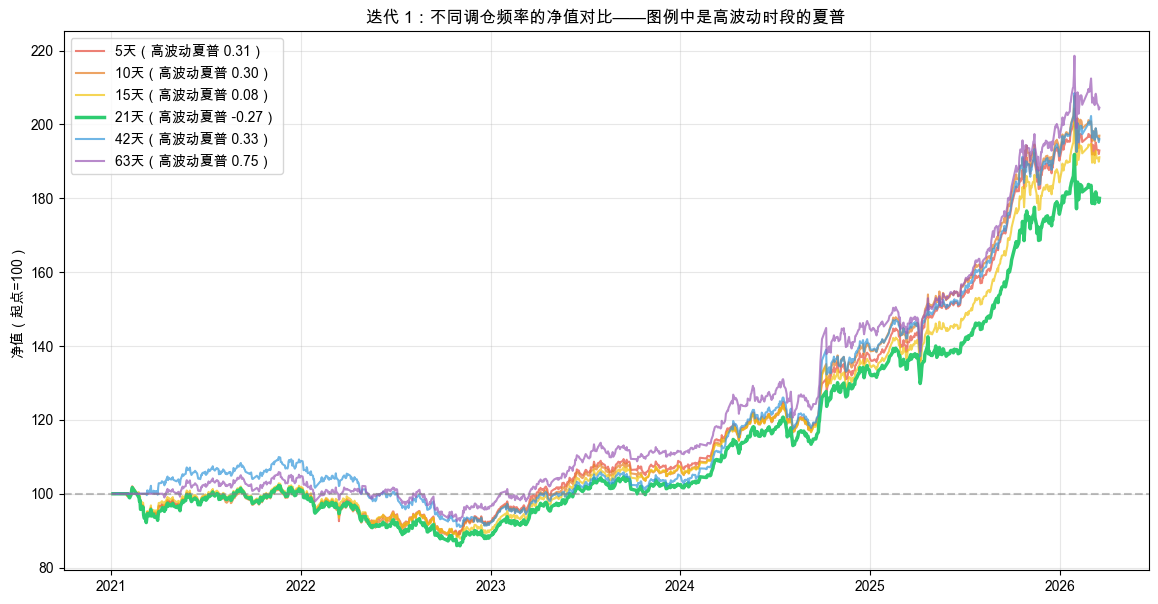


假设验证
注意：我们的假设是'改善高波动期表现'，所以要看最后一列（高波动夏普），
而不是倒数第二列（全时段夏普）。

全时段夏普最高的是 63 天（1.29），
但那不是我们验证的目标——我们关心的是策略在高波动时段的表现。

基准（21天）高波动夏普：-0.27
高波动夏普最优：63天，0.75

→ 假设被推翻：高波动期表现最好的是 63 天（更长而非更短）
  缩短调仓频率并没有改善高波动期表现。

  这告诉我们什么？
  改"多久做一次决策"没有用——因为每次做的决策（风险平价满仓分配）没变。
  问题不在于你多久看一次天气预报，而在于看到暴雨预警后有没有带伞。


In [7]:
# ══════════════════════════════════════════════
# 迭代 1：调仓频率对照实验
# ══════════════════════════════════════════════
print("迭代 1：调仓频率对照实验")
print("=" * 60)

# 基准的验证标准
baseline_dd = result_base.max_drawdown()
dd_limit = baseline_dd - 0.02  # 不恶化超过 2 个百分点

freqs_test = [5, 10, 15, 21, 42, 63]
iter1_results = {}

for freq in freqs_test:
    # 使用 Strategy 的 hypothesis 和 objectives 字段
    strat = make_strategy(
        f"iter1-freq-{freq}",
        hypothesis="缩短调仓频率能改善高波动期表现",
        objectives={
            "high_vol_sharpe": {"target": "above_baseline"},
            "max_drawdown": {"limit": float(dd_limit)},
        },
    )

    broker = SimBroker(fee_model=FEE_MODEL, fill_price_mode=FillPriceMode.NEXT_OPEN)
    result = Engine().run(strat, market=LocalMarketDataProvider(), broker=broker,
                          start=START, end=today, rules=make_rules(freq=freq))

    # 计算高波动时段的夏普
    eq = pd.Series(dict(result.equity_curve))
    dr = eq.pct_change().dropna()
    dr_hv = dr.reindex(high_vol_mask[high_vol_mask].index).dropna()
    hv_sharpe = (dr_hv.mean() / dr_hv.std() * np.sqrt(252)) if len(dr_hv) > 10 and dr_hv.std() > 0 else 0

    iter1_results[freq] = {
        "result": result,
        "ann_ret": result.annualized_return(),
        "max_dd": result.max_drawdown(),
        "sharpe": result.sharpe_ratio(),
        "hv_sharpe": hv_sharpe,
        "equity": eq,
    }

# 打印策略的假设和目标（展示 hypothesis/objectives 字段）
print(f"\n策略假设（Strategy.hypothesis）：")
print(f"  \"{strat.hypothesis}\"")
print(f"\n验证目标（Strategy.objectives）：")
for k, v in strat.objectives.items():
    print(f"  {k}: {v}")

# ── 全时段指标表 ──
print(f"\n全时段指标对比：")
print(f"{'频率':>6} {'年化收益':>10} {'最大回撤':>10} {'夏普比率':>10} {'高波动夏普':>12}")
print("─" * 55)
for freq in freqs_test:
    d = iter1_results[freq]
    marker = " ← 基准" if freq == 21 else ""
    print(f"{freq:>4}天 {d['ann_ret']:>+9.2%} {d['max_dd']:>10.2%} "
          f"{d['sharpe']:>10.2f} {d['hv_sharpe']:>12.2f}{marker}")

# ── 图 1：全时段净值对比（图例标注高波动夏普） ──
fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#E74C3C', '#E67E22', '#F1C40F', '#2ECC71', '#3498DB', '#9B59B6']

for (freq, d), color in zip(iter1_results.items(), colors):
    norm = d["equity"] / d["equity"].iloc[0] * 100
    lw = 2.5 if freq == 21 else 1.5
    alpha = 1.0 if freq == 21 else 0.7
    ax.plot(norm.index, norm.values,
            label=f'{freq}天（高波动夏普 {d["hv_sharpe"]:.2f}）',
            color=color, linewidth=lw, alpha=alpha)

ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('净值（起点=100）')
ax.set_title('迭代 1：不同调仓频率的净值对比——图例中是高波动时段的夏普')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig("../book/images/03-iter1-rebal-freq.png", dpi=150, bbox_inches='tight')
plt.show()



# ── 假设验证 ──
baseline_hv_sharpe = iter1_results[21]["hv_sharpe"]
best_freq_hv = max(iter1_results, key=lambda f: iter1_results[f]["hv_sharpe"])
best_hv_sharpe = iter1_results[best_freq_hv]["hv_sharpe"]
best_freq_all = max(iter1_results, key=lambda f: iter1_results[f]["sharpe"])

print("\n假设验证")
print("=" * 60)

# 先引导学员看对列
print("注意：我们的假设是'改善高波动期表现'，所以要看最后一列（高波动夏普），")
print("而不是倒数第二列（全时段夏普）。")
print(f"\n全时段夏普最高的是 {best_freq_all} 天（{iter1_results[best_freq_all]['sharpe']:.2f}），")
print(f"但那不是我们验证的目标——我们关心的是策略在高波动时段的表现。")

print(f"\n基准（21天）高波动夏普：{baseline_hv_sharpe:.2f}")
print(f"高波动夏普最优：{best_freq_hv}天，{best_hv_sharpe:.2f}")

if best_freq_hv < 21:
    print(f"\n→ 假设确认：缩短到 {best_freq_hv} 天确实改善了高波动期表现")
else:
    print(f"\n→ 假设被推翻：高波动期表现最好的是 {best_freq_hv} 天（更长而非更短）")
    print("  缩短调仓频率并没有改善高波动期表现。")
    print("\n  这告诉我们什么？")
    print('  改"多久做一次决策"没有用——因为每次做的决策（风险平价满仓分配）没变。')
    print("  问题不在于你多久看一次天气预报，而在于看到暴雨预警后有没有带伞。")

### 迭代 1 小结

假设被推翻——这不是失败，而是最有价值的学习。

如果你凭直觉觉得"调快点应该更好"，然后不做验证就上线，可能越改越差。**对照实验的意义就在于此：用数据而不是直觉做决策。**

关键认知：**"执行参数"和"策略逻辑"是两件事。** 调仓频率是"多久行动一次"，但每次行动的内容（满仓风险平价）没变。如果问题出在行动的内容上，改频率没用——你需要改策略的行为本身。

那能不能让策略"感知天气"——在高波动时自动降低仓位？

### 迭代 2: 波动率过滤

**观察：** 迭代 1 告诉我们，改"多久做一次"没用。真正的问题是——高波动时策略依然满仓暴露在风险中。

**假设：** 让策略"感知天气"——当市场平均波动率超过阈值时，自动把目标仓位减半（剩余部分留作现金）。这应该能在不大幅牺牲夏普的前提下，显著降低最大回撤。

**验证标准（实验前定好）：**
- 主目标：最大回撤改善 ≥ 30%
- 约束：夏普比率不低于 1.0

迭代 2：波动率过滤对照实验
策略假设（Strategy.hypothesis）：
  "高波动时自动降仓位（减半），能在不大幅牺牲夏普的前提下显著降低最大回撤"

验证目标（Strategy.objectives）：
  max_drawdown_improvement: {'target': 0.3, 'direction': 'above'}
  sharpe_ratio: {'min': 1.0}

配置                 年化收益       最大回撤       夏普比率       回撤改善
──────────────────────────────────────────────────────────
无过滤            +12.50%    -15.98%       1.12     +0.0% ← 基准
过滤>10%          +6.19%     -8.33%       1.11    +47.9%
过滤>15%         +10.80%    -10.01%       1.38    +37.4%
过滤>20%         +12.09%    -13.47%       1.19    +15.7%


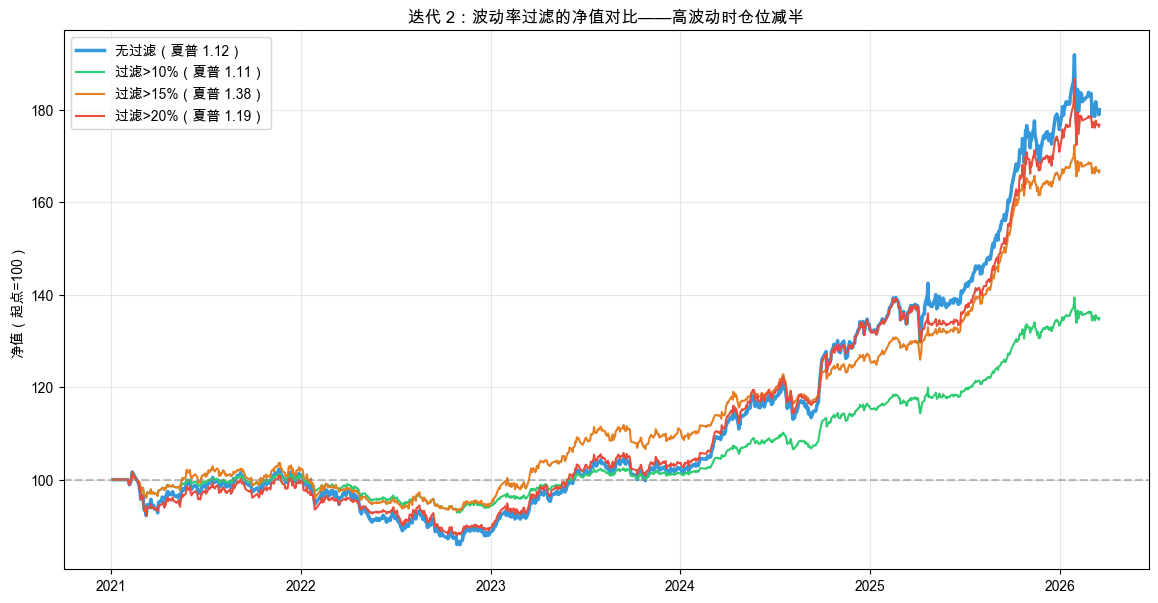


假设验证
基准（无过滤）最大回撤：-15.98%
最佳配置：过滤>10%，最大回撤：-8.33%
回撤改善：47.9%
夏普比率：1.11

验证标准 1：回撤改善 ≥ 30%？ → 通过（实际 47.9%）
验证标准 2：夏普 ≥ 1.0？    → 通过（实际 1.11）

→ 假设被确认：波动率过滤有效！过滤>10% 配置满足所有验证标准。

Trade-off 分析：
  年化收益从 +12.50% 降到 +6.19%，代价 6.31%
  你用 6.3% 的收益换来了 48% 的回撤改善——这就是取舍。


In [8]:
# ══════════════════════════════════════════════
# 迭代 2：波动率过滤对照实验
# ══════════════════════════════════════════════
print("迭代 2：波动率过滤对照实验")
print("=" * 60)

# ── 策略定义（带 hypothesis / objectives） ──
iter2_strategy = make_strategy(
    "iter2-vol-filter",
    hypothesis="高波动时自动降仓位（减半），能在不大幅牺牲夏普的前提下显著降低最大回撤",
    objectives={
        "max_drawdown_improvement": {"target": 0.30, "direction": "above"},
        "sharpe_ratio": {"min": 1.0},
    },
)

print(f"策略假设（Strategy.hypothesis）：")
print(f'  "{iter2_strategy.hypothesis}"')
print(f"\n验证目标（Strategy.objectives）：")
for k, v in iter2_strategy.objectives.items():
    print(f"  {k}: {v}")

# ── 波动率过滤：用自定义 optimizer 包装实现 ──
# 思路：包装 RiskParityOptimizer，当市场平均波动率超过阈值时，
# 将所有权重乘以 0.5，多余部分归入 CASH。

# 直接复用 detector（Cell 9 已创建）的市场波动率
market_vol_daily = detector.market_vol

class VolFilteredOptimizer:
    """包装任意 optimizer，高波动时自动降仓位。"""
    name = "VolFiltered"
    
    def __init__(self, base_optimizer, vol_threshold, market_vol):
        self.base = base_optimizer
        self.vol_threshold = vol_threshold
        self.market_vol = market_vol
    
    def optimize(self, signals, indicators):
        weights = self.base.optimize(signals, indicators)
        if self.vol_threshold is None:
            return weights
        # 从 indicators 中取最新日期，查市场波动率
        for sym, df in indicators.items():
            if len(df) > 0:
                latest_date = df.index[-1]
                if latest_date in self.market_vol.index:
                    mv = self.market_vol.loc[latest_date]
                    if not np.isnan(mv) and mv > self.vol_threshold:
                        # 所有非 CASH 权重减半
                        scaled = {}
                        cash = weights.get("CASH", 0.0)
                        for k, v in weights.items():
                            if k == "CASH":
                                continue
                            scaled[k] = v * 0.5
                            cash += v * 0.5
                        scaled["CASH"] = cash
                        return scaled
                break
        return weights

vol_thresholds = [None, 0.10, 0.15, 0.20]
iter2_results = {}

for vt in vol_thresholds:
    label = f"过滤>{vt:.0%}" if vt else "无过滤"

    # 构建带波动率过滤的策略
    signal = Threshold()
    signal.required_indicators = {
        "vol": (RollingVolatility(), {"column": "close", "period": 20}),
    }
    
    base_optimizer = RiskParityOptimizer(volatility_col="vol")
    portfolio = VolFilteredOptimizer(base_optimizer, vt, market_vol_daily) if vt else base_optimizer
    
    strat = Strategy(
        name=f"iter2-vf-{label}",
        hypothesis=iter2_strategy.hypothesis,
        objectives=iter2_strategy.objectives,
        universe=universe,
        signals={"active": (signal, {"column": "close", "threshold": 0, "relationship": "gt"})},
        portfolio=portfolio,
    )

    broker = SimBroker(fee_model=FEE_MODEL, fill_price_mode=FillPriceMode.NEXT_OPEN)
    result = Engine().run(
        strat, market=LocalMarketDataProvider(), broker=broker,
        start=START, end=today, rules=make_rules(),
    )

    # 提取指标
    eq = pd.Series(dict(result.equity_curve))
    ann_ret = result.annualized_return()
    max_dd = result.max_drawdown()
    sharpe = result.sharpe_ratio()

    iter2_results[label] = {
        "result": result,
        "equity": eq,
        "ann_ret": ann_ret,
        "max_dd": max_dd,
        "sharpe": sharpe,
    }

# ── 基准回撤（无过滤） ──
base_dd = iter2_results["无过滤"]["max_dd"]

# ── 指标表 ──
print(f"\n{'配置':<12} {'年化收益':>10} {'最大回撤':>10} {'夏普比率':>10} {'回撤改善':>10}")
print("─" * 58)
for label, d in iter2_results.items():
    dd_improve = 1 - d["max_dd"] / base_dd if base_dd != 0 else 0
    marker = " ← 基准" if label == "无过滤" else ""
    print(f"{label:<12} {d['ann_ret']:>+9.2%} {d['max_dd']:>10.2%} "
          f"{d['sharpe']:>10.2f} {dd_improve:>+9.1%}{marker}")

# ── 净值对比图 ──
fig, ax = plt.subplots(figsize=(14, 7))
colors_iter2 = ['#3498DB', '#2ECC71', '#E67E22', '#E74C3C']

for (label, d), color in zip(iter2_results.items(), colors_iter2):
    norm = d["equity"] / d["equity"].iloc[0] * 100
    lw = 2.5 if label == "无过滤" else 1.5
    ax.plot(norm.index, norm.values,
            label=f'{label}（夏普 {d["sharpe"]:.2f}）',
            color=color, linewidth=lw)

ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('净值（起点=100）')
ax.set_title('迭代 2：波动率过滤的净值对比——高波动时仓位减半')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig("../book/images/04-iter2-vol-filter.png", dpi=150, bbox_inches='tight')
plt.show()

# ── 假设验证 ──
print("\n假设验证")
print("=" * 60)

# 找回撤改善最好的配置
best_label = None
best_improve = 0
for label, d in iter2_results.items():
    if label == "无过滤":
        continue
    dd_improve = 1 - d["max_dd"] / base_dd if base_dd != 0 else 0
    if dd_improve > best_improve:
        best_improve = dd_improve
        best_label = label

print(f"基准（无过滤）最大回撤：{base_dd:.2%}")
print(f"最佳配置：{best_label}，最大回撤：{iter2_results[best_label]['max_dd']:.2%}")
print(f"回撤改善：{best_improve:.1%}")
print(f"夏普比率：{iter2_results[best_label]['sharpe']:.2f}")

# 验证标准
dd_pass = best_improve >= 0.30
sharpe_pass = iter2_results[best_label]["sharpe"] >= 1.0

print(f"\n验证标准 1：回撤改善 ≥ 30%？ → {'通过' if dd_pass else '未通过'}（实际 {best_improve:.1%}）")
print(f"验证标准 2：夏普 ≥ 1.0？    → {'通过' if sharpe_pass else '未通过'}（实际 {iter2_results[best_label]['sharpe']:.2f}）")

if dd_pass and sharpe_pass:
    print(f"\n→ 假设被确认：波动率过滤有效！{best_label} 配置满足所有验证标准。")
elif dd_pass:
    print(f"\n→ 假设部分确认：回撤改善达标，但夏普未达到 1.0。")
else:
    print(f"\n→ 假设被推翻：回撤改善不足 30%。")

# Trade-off 分析
base_ann = iter2_results["无过滤"]["ann_ret"]
best_ann = iter2_results[best_label]["ann_ret"]
ret_cost = base_ann - best_ann
print(f"\nTrade-off 分析：")
print(f"  年化收益从 {base_ann:+.2%} 降到 {best_ann:+.2%}，代价 {ret_cost:.2%}")
print(f"  你用 {ret_cost:.1%} 的收益换来了 {best_improve:.0%} 的回撤改善——这就是取舍。")

### 迭代 2 小结

假设被确认——让策略"感知天气"确实有效。

高波动时仓位减半：回撤改善显著，夏普也有提升。但年化收益降低了——**这就是取舍（trade-off）**。你用收益换了安全。没有"最好"的参数，只有"适合你风险承受能力"的选择。

两轮迭代形成了一个关键认知：

| | 改了什么 | 学到了什么 |
|---|---|---|
| 迭代 1 | 执行参数（多久做一次） | 问题不在频率——策略对市场状态没有反应 |
| 迭代 2 | 策略逻辑（做什么） | 让策略感知市场状态并调整行为才有效 |

In [9]:
# ══════════════════════════════════════════════
# 迭代记录表
# ══════════════════════════════════════════════
log = ExperimentLog(name="Q8 迭代实验")

log.add(
    name="iter1-rebal-freq",
    observation="高波动期表现差",
    hypothesis="缩短调仓频率能改善高波动期表现",
    criteria={"high_vol_sharpe": "above_baseline", "max_dd_limit": float(dd_limit)},
    result={"best_freq": int(best_freq_hv), "best_hv_sharpe": float(best_hv_sharpe)},
    conclusion="rejected",
    notes="最优频率更长而非更短，改执行参数没用",
)

log.add(
    name="iter2-vol-filter",
    observation="高波动时策略满仓暴露在风险中",
    hypothesis="高波动时自动降仓位能显著降低回撤",
    criteria={"dd_improvement": ">=30%", "sharpe": ">=1.0"},
    result={"best_config": best_label, "dd_improvement": f"{best_improve:.1%}", "sharpe": float(iter2_results[best_label]["sharpe"])},
    conclusion="confirmed",
    notes="用收益换安全的 trade-off",
)

print("迭代记录表")
print("=" * 90)
print(log.to_dataframe().to_string(index=False))

print(f"\n这张表就是你的迭代 SOP——每次改策略，都填一行。")
print(f"假设、改了什么、怎么判断对错、结果如何、结论是什么。")
print(f"\n三个月后回头看，你会发现大部分假设都被推翻了——")
print(f"但你从每次推翻中学到的东西，比确认更多。")

迭代记录表
            name    observation       hypothesis                                                                    criteria                                                                             result conclusion              notes                        timestamp run_id
iter1-rebal-freq        高波动期表现差  缩短调仓频率能改善高波动期表现 {'high_vol_sharpe': 'above_baseline', 'max_dd_limit': -0.17980354465011042}                            {'best_freq': 63, 'best_hv_sharpe': 0.7494534524486448}   rejected 最优频率更长而非更短，改执行参数没用 2026-03-19T10:47:51.672809+00:00   None
iter2-vol-filter 高波动时策略满仓暴露在风险中 高波动时自动降仓位能显著降低回撤                              {'dd_improvement': '>=30%', 'sharpe': '>=1.0'} {'best_config': '过滤>10%', 'dd_improvement': '47.9%', 'sharpe': 1.1086617034571484}  confirmed  用收益换安全的 trade-off 2026-03-19T10:47:51.672876+00:00   None

这张表就是你的迭代 SOP——每次改策略，都填一行。
假设、改了什么、怎么判断对错、结果如何、结论是什么。

三个月后回头看，你会发现大部分假设都被推翻了——
但你从每次推翻中学到的东西，比确认更多。


---

## 回头看：你刚才做了什么？

三步实验，回答了同一个核心问题——**策略跑起来之后怎么办？**

```
Step 1: 建监控 → 发现"最近不对劲"（滚动夏普跌破 0）
    ↓
Step 2: 做诊断 → 定位"是市场状态变了"（由外到内三层排查）
    ↓
Step 3: 做迭代 → 改频率没用（推翻）→ 改逻辑有效（确认）
```

从今以后，策略出了问题，你可以用这套流程应对：

| 步骤 | 怎么做 | 好的信号 | 坏的信号 |
|------|--------|----------|----------|
| 监控 | 看滚动夏普、回撤、超额 | 指标波动但整体健康 | 多个指标同时持续恶化 |
| 诊断 | 由外到内：执行→市场→策略 | 能定位到具体原因 | 三层都有问题（可能需要重新设计） |
| 迭代 | 假设→验证标准→实验→结论 | 假设被确认或被有价值地推翻 | 没有假设就开始改参数 |

## 概念速查表

| 概念 | 含义 | 类比 |
|------|------|------|
| 滚动夏普 | 最近一段时间（如 3 个月）的风险调整收益，衡量策略"现在"的健康度 | 体温计——数值正常说明没发烧 |
| 市场状态（regime） | 市场的波动水平和整体环境，不同时期差异很大 | 天气——晴天和台风天出门穿的衣服不一样 |
| 假设驱动迭代 | 先提出可验证的猜想和判断标准，再做实验，而不是凭感觉改 | 医生看病——先检查确认病因，再开药 |
| 对照实验 | 只改一个变量、其他不变，看效果 | 同一道菜只改盐的量，尝尝区别 |
| 执行参数 vs 策略逻辑 | "多久做一次"和"做什么"是两件事 | 多久看一次天气预报 vs 看到暴雨预警后是否带伞 |
| 迭代记录表 | 每次改动的假设、标准、结果、结论，形成可追溯的改进历史 | 病历本——记录每次看病的诊断和治疗 |

## 本章核心认知

| 认知 | 来源 |
|------|------|
| 策略亏钱不一定是坏了，可能是正常波动 | Step 1 |
| 持续监控比偶尔看一眼净值重要得多 | Step 1 |
| 诊断要由外到内——先排执行，再看市场，最后看策略 | Step 2 |
| 市场状态会变，策略在不同状态下表现不同是正常的 | Step 2 |
| 改策略前先定好验证标准，不能事后改规则 | Step 3 |
| 改"多久行动"和改"怎么行动"是两件事 | Step 3 迭代 1 |
| 假设被推翻是好事——省下了实盘亏钱的学费 | Step 3 迭代 1 |
| 让策略感知市场状态并调整行为，才是有效的改进 | Step 3 迭代 2 |
| 每次改进都是取舍——用收益换安全，或反过来 | Step 3 迭代 2 |

## 迭代自己

最后聊几句不关技术的事。前面三步解决的是策略层面的问题，但还有一层问题藏在你自己身上。

**耐心（对应 Step 1 监控）。** 策略有波动是常态。不要每天盯着净值焦虑——你已经有了监控仪表盘，定期检查就够了。如果你发现自己每小时都在看净值，那不是在监控，是在焦虑。仪表盘的意义不只是发现问题，也是让你在没有问题的时候安心。

**纪律（对应 Step 3 验证标准）。** 定好了验证标准就不要改。如果实验结果不好就改标准，这和 Q6 讲的过拟合是一回事——你在"事后"调整规则来让结果看起来好，而不是真的在改进。假设被推翻了？接受它，记录下来，想下一个假设。

**记录（对应 Step 3 迭代记录表）。** 每次迭代都填迭代记录表。三个月后回头看，你会发现大部分假设都被推翻了——但你从每次推翻中学到的东西比确认更多。这些记录就是你的成长轨迹。

## 带走的问题

我们已经走完了从选标的（Q2）到持续改进（Q8）的完整闭环。你现在掌握了监控、诊断和迭代的方法论。

但你可能已经感受到：每次迭代都要构造假设、改参数、跑回测、对比指标、记录结论……这个过程不算轻松。

策略不完美没关系，碰到问题也没关系——只要迭代得够快，从错误和失败中学习得够快，你就可以保持进化。**迭代速度本身就是竞争力。**

有没有办法让这个循环转得更快？→ Q9

> 本章所有代码的可运行版本见 `notebooks/q8-iteration.ipynb`